First 5 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Category Counts:
Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64


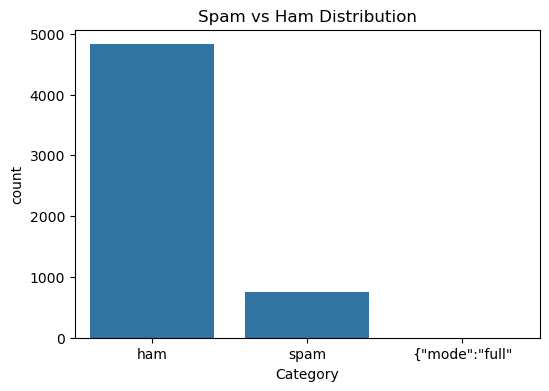

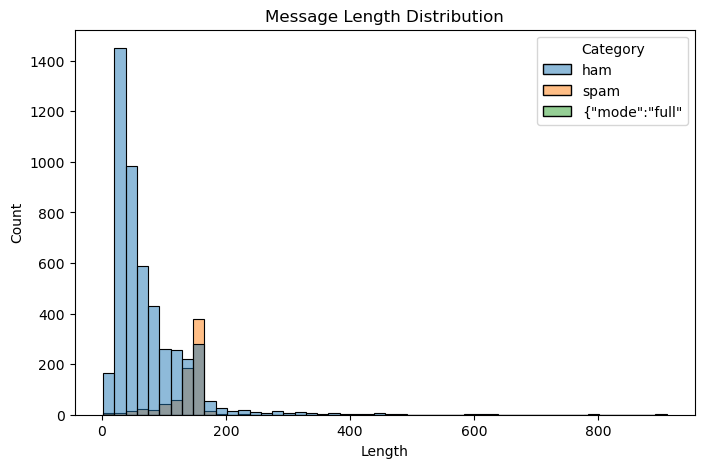

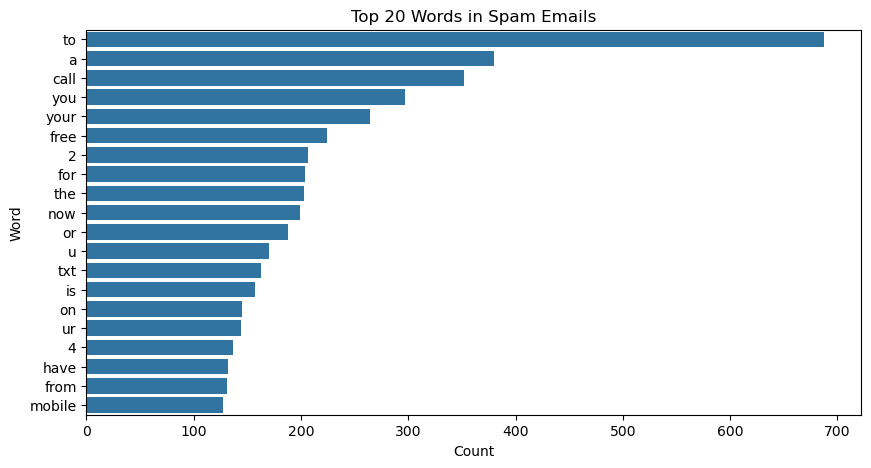


Accuracy: 0.9757847533632287

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       958
        spam       1.00      0.83      0.91       157

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.97      1115



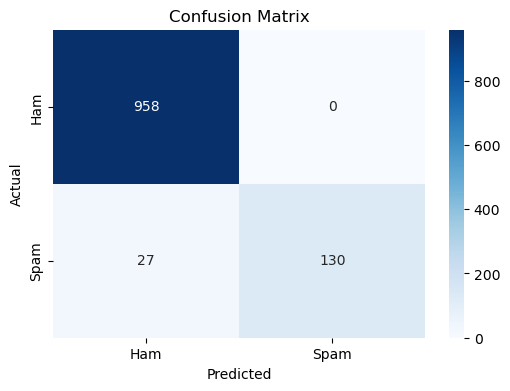


Custom Email Tests:
Email 1: spam
Email 2: ham


In [1]:
# ================================
# SPAM EMAIL DETECTION PROJECT
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("email.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nCategory Counts:")
print(df['Category'].value_counts())

# -------------------------------
# Visualization: Spam vs Ham
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

# -------------------------------
# Text Preprocessing
# -------------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['Cleaned_Message'] = df['Message'].apply(clean_text)

# -------------------------------
# Message Length Analysis
# -------------------------------
df['Length'] = df['Message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Length', hue='Category', bins=50)
plt.title("Message Length Distribution")
plt.show()

# -------------------------------
# Top 20 Words in Spam Emails
# -------------------------------
spam_words = ' '.join(df[df['Category']=='spam']['Cleaned_Message']).split()

spam_common = Counter(spam_words).most_common(20)

spam_df = pd.DataFrame(spam_common, columns=['Word','Count'])

plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Word', data=spam_df)
plt.title("Top 20 Words in Spam Emails")
plt.show()

# -------------------------------
# TF-IDF Feature Extraction
# -------------------------------
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Cleaned_Message'])
y = df['Category']

# -------------------------------
# Train Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Train Model
# -------------------------------
model = MultinomialNB()
model.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# Model Evaluation
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# Custom Email Prediction
# -------------------------------
def predict_email(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    return prediction[0]

print("\nCustom Email Tests:")
print("Email 1:", predict_email("Congratulations! You have won a lottery prize"))
print("Email 2:", predict_email("Hi, are we meeting tomorrow?"))